In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader

from torchvision.models.detection import (
    maskrcnn_resnet50_fpn,
    MaskRCNN_ResNet50_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform

from tqdm.auto import tqdm
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, confusion_matrix, classification_report,
)

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/Mammogram_Shape_Preprocess"
MODEL_SAVE_PATH = os.path.join(PROJECT_PATH, "best_maskrcnn_v2.pth")

LABEL_NAMES_RAW = {0: "IRREGULAR", 1: "OVAL", 2: "LOBULATED"}       # raw npy labels
LABEL_NAMES_MODEL = {1: "IRREGULAR", 2: "OVAL", 3: "LOBULATED"}      # model labels (0=bg)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [4]:
X_train = np.load(os.path.join(PROJECT_PATH, "NEW_ROI_X_train.npy"))
X_val   = np.load(os.path.join(PROJECT_PATH, "NEW_ROI_X_val.npy"))
X_test  = np.load(os.path.join(PROJECT_PATH, "NEW_ROI_X_test.npy"))

Y_train = np.load(os.path.join(PROJECT_PATH, "NEW_ROI_Y_train.npy"))
Y_val   = np.load(os.path.join(PROJECT_PATH, "NEW_ROI_Y_val.npy"))
Y_test  = np.load(os.path.join(PROJECT_PATH, "NEW_ROI_Y_test.npy"))

shape_train = np.load(os.path.join(PROJECT_PATH, "roi_shape_train.npy"))
shape_val   = np.load(os.path.join(PROJECT_PATH, "roi_shape_val.npy"))
shape_test  = np.load(os.path.join(PROJECT_PATH, "roi_shape_test.npy"))

print("Train:", X_train.shape, Y_train.shape, shape_train.shape)
print("Val:  ", X_val.shape, Y_val.shape, shape_val.shape)
print("Test: ", X_test.shape, Y_test.shape, shape_test.shape)

Train: (1004, 128, 128, 1) (1004, 128, 128, 1) (1004,)
Val:   (126, 128, 128, 1) (126, 128, 128, 1) (126,)
Test:  (130, 128, 128, 1) (130, 128, 128, 1) (130,)


In [5]:
class MammogramDataset(Dataset):
    """
    Each image has exactly one mass -> exactly one box/mask/label.
    Augmentation (train only): random horizontal flip, vertical flip,
    and 90-degree rotation, applied identically to image + mask.
    """

    def __init__(self, images, masks, labels, augment=False):
        self.images = images
        self.masks = masks
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def _augment(self, image, mask):
        # image: (H, W, 1) float32, mask: (H, W) uint8
        if random.random() < 0.5:
            image = np.flip(image, axis=1).copy()
            mask = np.flip(mask, axis=1).copy()
        if random.random() < 0.5:
            image = np.flip(image, axis=0).copy()
            mask = np.flip(mask, axis=0).copy()
        k = random.choice([0, 1, 2, 3])
        if k:
            image = np.rot90(image, k, axes=(0, 1)).copy()
            mask = np.rot90(mask, k, axes=(0, 1)).copy()
        return image, mask

    def __getitem__(self, idx):
        image = self.images[idx]                    # (H, W, 1)
        mask = self.masks[idx].squeeze()             # (H, W)
        mask = (mask > 0).astype(np.uint8)

        if self.augment:
            image, mask = self._augment(image, mask)

        pos = np.where(mask)
        # Guard against a degenerate (all-zero) mask after augmentation/edge cases
        if len(pos[0]) == 0:
            xmin, xmax, ymin, ymax = 0, mask.shape[1] - 1, 0, mask.shape[0] - 1
        else:
            xmin, xmax = pos[1].min(), pos[1].max()
            ymin, ymax = pos[0].min(), pos[0].max()
            if xmax == xmin:
                xmax += 1
            if ymax == ymin:
                ymax += 1

        image = np.repeat(image, 3, axis=-1)
        image = torch.as_tensor(image, dtype=torch.float32).permute(2, 0, 1)

        boxes = torch.tensor([[xmin, ymin, xmax, ymax]], dtype=torch.float32)
        label = int(self.labels[idx]) + 1  # offset for background=0
        labels = torch.tensor([label], dtype=torch.int64)
        masks = torch.tensor(mask[np.newaxis, :, :], dtype=torch.uint8)
        area = torch.tensor([(xmax - xmin) * (ymax - ymin)], dtype=torch.float32)
        iscrowd = torch.zeros((1,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd,
        }
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = MammogramDataset(X_train, Y_train, shape_train, augment=True)
val_dataset   = MammogramDataset(X_val,   Y_val,   shape_val,   augment=False)
test_dataset  = MammogramDataset(X_test,  Y_test,  shape_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)

In [6]:
def build_model(num_classes=4, freeze_backbone=False):
    weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
    model = maskrcnn_resnet50_fpn(weights=weights)

    # --- Replace heads for our 3 shape classes + background ---
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    model.transform = GeneralizedRCNNTransform(
        min_size=256, max_size=256,
        image_mean=[0.485, 0.456, 0.406],
        image_std=[0.229, 0.224, 0.225],
    )

    anchor_generator = AnchorGenerator(
        sizes=((8,), (16,), (32,), (64,), (128,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5,
    )
    model.rpn.anchor_generator = anchor_generator

    if freeze_backbone:
        for param in model.backbone.parameters():
            param.requires_grad = False
        print("Backbone frozen.")

    model.to(device)
    return model


model = build_model(num_classes=4, freeze_backbone=False)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 181MB/s]


Total parameters     : 43,933,159
Trainable parameters : 43,710,759


In [7]:
backbone_params = [p for n, p in model.named_parameters()
                    if p.requires_grad and n.startswith("backbone")]
head_params = [p for n, p in model.named_parameters()
                if p.requires_grad and not n.startswith("backbone")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": head_params, "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

In [8]:
@torch.no_grad()
def predict_top1(model, image_tensor):
    model.eval()
    prediction = model([image_tensor.to(device)])[0]
    if len(prediction["scores"]) == 0:
        h, w = image_tensor.shape[-2:]
        return np.zeros((h, w), dtype=np.uint8), 0, 0.0
    best = prediction["scores"].argmax()
    mask = prediction["masks"][best, 0].cpu().numpy()
    mask = (mask > 0.5).astype(np.uint8)
    label = prediction["labels"][best].item()
    score = prediction["scores"][best].item()
    return mask, label, score


def dice_score(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    inter = np.logical_and(gt, pred).sum()
    return (2 * inter + 1e-8) / (gt.sum() + pred.sum() + 1e-8)


def iou_score(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    return (inter + 1e-8) / (union + 1e-8)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    dices, ious = [], []
    true_labels, pred_labels, scores = [], [], []

    for images, targets in loader:
        image = images[0]
        gt_mask = targets[0]["masks"][0].numpy()
        gt_label = targets[0]["labels"].item()

        pred_mask, pred_label, score = predict_top1(model, image)
        # resize pred_mask back if the model's internal transform changed
        # output size relative to gt (torchvision resizes predictions back
        # to the input image size automatically, so shapes should already
        # match — this assert catches it early if not).
        assert pred_mask.shape == gt_mask.shape, (pred_mask.shape, gt_mask.shape)

        dices.append(dice_score(gt_mask, pred_mask))
        ious.append(iou_score(gt_mask, pred_mask))
        true_labels.append(gt_label)
        pred_labels.append(pred_label)
        scores.append(score)

    return {
        "dice": float(np.mean(dices)),
        "iou": float(np.mean(ious)),
        "accuracy": accuracy_score(true_labels, pred_labels),
        "true_labels": true_labels,
        "pred_labels": pred_labels,
        "scores": scores,
    }


def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    progress = tqdm(loader)
    for images, targets in progress:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [9]:
os.makedirs(PROJECT_PATH, exist_ok=True)

num_epochs = 30
patience = 7
best_dice = -1.0
epochs_no_improve = 0

history = {"train_loss": [], "val_dice": [], "val_iou": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_metrics = evaluate(model, val_loader)

    scheduler.step(val_metrics["dice"])

    history["train_loss"].append(train_loss)
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_acc"].append(val_metrics["accuracy"])

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Dice   : {val_metrics['dice']:.4f}")
    print(f"Val IoU    : {val_metrics['iou']:.4f}")
    print(f"Val Acc    : {val_metrics['accuracy']:.4f}")

    if val_metrics["dice"] > best_dice:
        best_dice = val_metrics["dice"]
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("Best model saved.")
    else:
        epochs_no_improve += 1
        print(f"No improvement: {epochs_no_improve}/{patience}")
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

  0%|          | 0/251 [00:00<?, ?it/s]


Epoch 1/30
Train Loss : 0.4501
Val Dice   : 0.7880
Val IoU    : 0.6764
Val Acc    : 0.4206
Best model saved.


  0%|          | 0/251 [00:00<?, ?it/s]


Epoch 2/30
Train Loss : 0.3676
Val Dice   : 0.7946
Val IoU    : 0.6830
Val Acc    : 0.3810
Best model saved.


  0%|          | 0/251 [00:00<?, ?it/s]

...


Epoch 28/30
Train Loss : 0.2258
Val Dice   : 0.8635
Val IoU    : 0.7710
Val Acc    : 0.5714
No improvement: 2/7


  0%|          | 0/251 [00:00<?, ?it/s]


Epoch 29/30
Train Loss : 0.2284
Val Dice   : 0.8587
Val IoU    : 0.7633
Val Acc    : 0.5159
No improvement: 3/7


  0%|          | 0/251 [00:00<?, ?it/s]


Epoch 30/30
Train Loss : 0.2262
Val Dice   : 0.8523
Val IoU    : 0.7582
Val Acc    : 0.5000
No improvement: 4/7


Best model loaded.

=== Train ===
Dice     : 0.8984
IoU      : 0.8209
Accuracy : 0.6375

=== Validation ===
Dice     : 0.8701
IoU      : 0.7763
Accuracy : 0.5714

=== Test ===
Dice     : 0.8066
IoU      : 0.7119
Accuracy : 0.5462
              precision    recall  f1-score   support

   IRREGULAR       0.60      0.66      0.63        58
        OVAL       0.52      0.52      0.52        42
   LOBULATED       0.44      0.37      0.40        30

    accuracy                           0.55       130
   macro avg       0.52      0.52      0.52       130
weighted avg       0.54      0.55      0.54       130



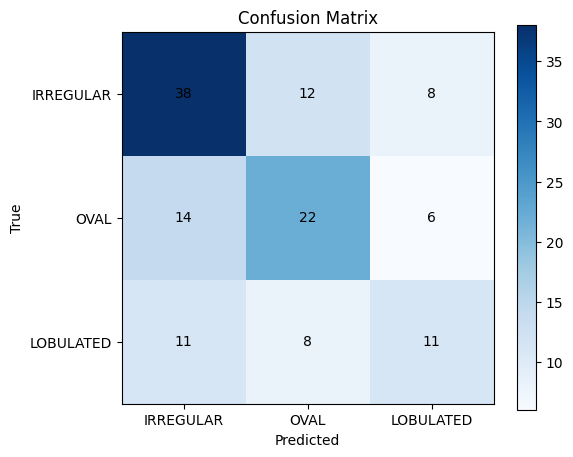

In [11]:
model = build_model(num_classes=4, freeze_backbone=False)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.to(device)
model.eval()
print("Best model loaded.")

for name, loader in [("Train", train_loader), ("Validation", val_loader), ("Test", test_loader)]:
    m = evaluate(model, loader)
    print(f"\n=== {name} ===")
    print(f"Dice     : {m['dice']:.4f}")
    print(f"IoU      : {m['iou']:.4f}")
    print(f"Accuracy : {m['accuracy']:.4f}")
    if name == "Test":
        print(classification_report(
            m["true_labels"], m["pred_labels"],
            labels=[1, 2, 3],
            target_names=["IRREGULAR", "OVAL", "LOBULATED"],
            zero_division=0,
        ))
        cm = confusion_matrix(m["true_labels"], m["pred_labels"], labels=[1, 2, 3])
        plt.figure(figsize=(6, 5))
        plt.imshow(cm, cmap="Blues")
        plt.xticks([0, 1, 2], ["IRREGULAR", "OVAL", "LOBULATED"])
        plt.yticks([0, 1, 2], ["IRREGULAR", "OVAL", "LOBULATED"])
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
        for i in range(3):
            for j in range(3):
                plt.text(j, i, cm[i, j], ha="center", va="center")
        plt.colorbar()
        plt.show()

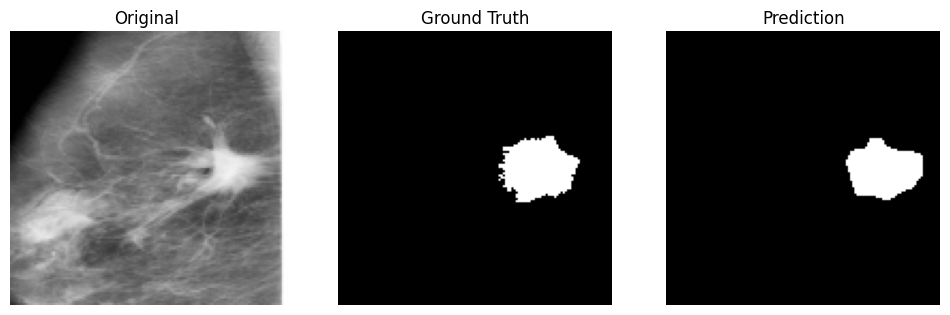

True : IRREGULAR
Pred : IRREGULAR (score=0.983)


In [12]:
idx = random.randint(0, len(X_test) - 1)
image_tensor, target = test_dataset[idx]
pred_mask, pred_label, score = predict_top1(model, image_tensor)
gt_mask = target["masks"][0].numpy()
gt_label = target["labels"].item()

plt.figure(figsize=(12, 4))
plt.subplot(131); plt.imshow(X_test[idx].squeeze(), cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(132); plt.imshow(gt_mask, cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
plt.subplot(133); plt.imshow(pred_mask, cmap="gray"); plt.title("Prediction"); plt.axis("off")
plt.show()
print("True :", LABEL_NAMES_MODEL.get(gt_label, "Background"))
print("Pred :", LABEL_NAMES_MODEL.get(pred_label, "No Detection"), f"(score={score:.3f})")